In [46]:
import pandas as pd

In [47]:
columns = [
    "age", "sex", "chest_pain", "resting_bp", "cholesterol",
    "fasting_bs", "rest_ecg", "max_hr", "exercise_angina",
    "oldpeak", "slope", "num_vessels", "thal", "target"
]

df = pd.read_csv('statlog+heart/heart.dat', sep=' ', names=columns)
df
#space separated data

,age,sex,chest_pain,resting_bp,cholesterol,fasting_bs,rest_ecg,max_hr,exercise_angina,oldpeak,slope,num_vessels,thal,target
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,2
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,1
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,2
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,1
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52.0,1.0,3.0,172.0,199.0,1.0,0.0,162.0,0.0,0.5,1.0,0.0,7.0,1
266,44.0,1.0,2.0,120.0,263.0,0.0,0.0,173.0,0.0,0.0,1.0,0.0,7.0,1
267,56.0,0.0,2.0,140.0,294.0,0.0,2.0,153.0,0.0,1.3,2.0,0.0,3.0,1
268,57.0,1.0,4.0,140.0,192.0,0.0,0.0,148.0,0.0,0.4,2.0,0.0,6.0,1


###Data Preprocessing

In [48]:
df['target'] = df['target'].map({1: 0, 2: 1})

#target variable is:
# 1 = Absence (No disease)
# 2 = Presence (Disease)

#But ML models work best with:
# 0 = No disease
# 1 = Disease

In [49]:
#Apply One-Hot Encoding
df = pd.get_dummies(df, columns=[
    'chest_pain', 'rest_ecg', 'slope', 'thal'
], drop_first=True)
df

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,num_vessels,target,chest_pain_2.0,chest_pain_3.0,chest_pain_4.0,rest_ecg_1.0,rest_ecg_2.0,slope_2.0,slope_3.0,thal_6.0,thal_7.0
0,70.0,1.0,130.0,322.0,0.0,109.0,0.0,2.4,3.0,1,False,False,True,False,True,True,False,False,False
1,67.0,0.0,115.0,564.0,0.0,160.0,0.0,1.6,0.0,0,False,True,False,False,True,True,False,False,True
2,57.0,1.0,124.0,261.0,0.0,141.0,0.0,0.3,0.0,1,True,False,False,False,False,False,False,False,True
3,64.0,1.0,128.0,263.0,0.0,105.0,1.0,0.2,1.0,0,False,False,True,False,False,True,False,False,True
4,74.0,0.0,120.0,269.0,0.0,121.0,1.0,0.2,1.0,0,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52.0,1.0,172.0,199.0,1.0,162.0,0.0,0.5,0.0,0,False,True,False,False,False,False,False,False,True
266,44.0,1.0,120.0,263.0,0.0,173.0,0.0,0.0,0.0,0,True,False,False,False,False,False,False,False,True
267,56.0,0.0,140.0,294.0,0.0,153.0,0.0,1.3,0.0,0,True,False,False,False,True,True,False,False,False
268,57.0,1.0,140.0,192.0,0.0,148.0,0.0,0.4,0.0,0,False,False,True,False,False,True,False,True,False


In [50]:
print(df.info())
print(df.describe())
print(df['target'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              270 non-null    float64
 1   sex              270 non-null    float64
 2   resting_bp       270 non-null    float64
 3   cholesterol      270 non-null    float64
 4   fasting_bs       270 non-null    float64
 5   max_hr           270 non-null    float64
 6   exercise_angina  270 non-null    float64
 7   oldpeak          270 non-null    float64
 8   num_vessels      270 non-null    float64
 9   target           270 non-null    int64  
 10  chest_pain_2.0   270 non-null    bool   
 11  chest_pain_3.0   270 non-null    bool   
 12  chest_pain_4.0   270 non-null    bool   
 13  rest_ecg_1.0     270 non-null    bool   
 14  rest_ecg_2.0     270 non-null    bool   
 15  slope_2.0        270 non-null    bool   
 16  slope_3.0        270 non-null    bool   
 17  thal_6.0        

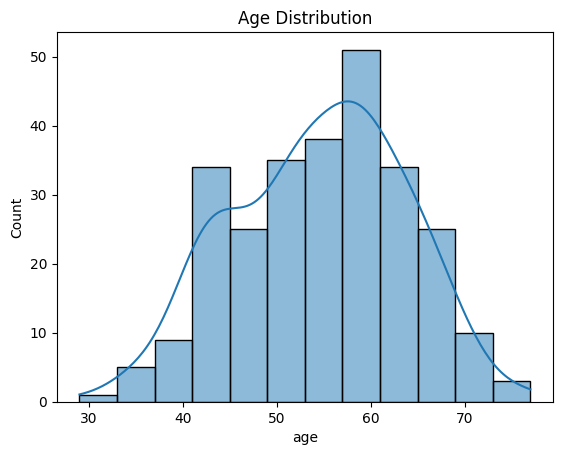

In [51]:
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

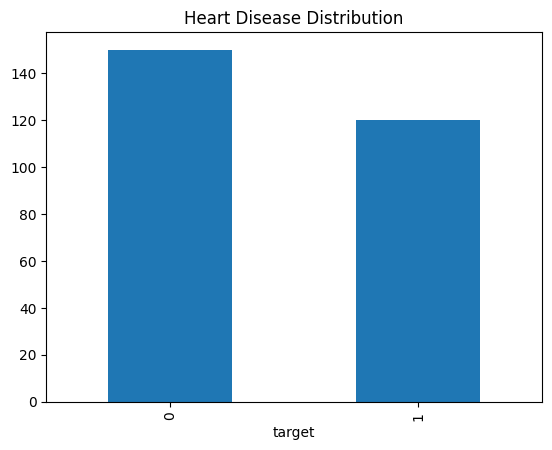

In [52]:
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.show()

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

<Axes: xlabel='cholesterol'>

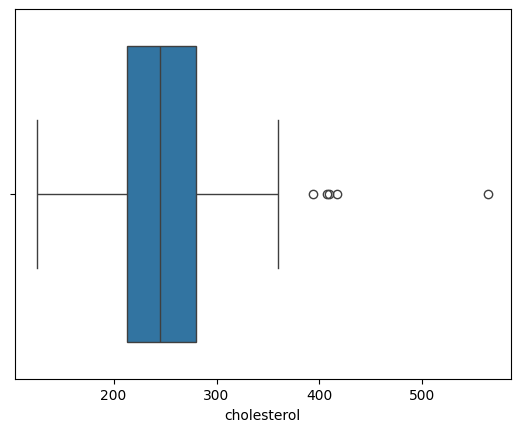

In [55]:
import seaborn as sns

sns.boxplot(x=df['cholesterol'])

#I analyzed outliers but retained them because they represent real patients

###Model training

In [56]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}


Model: Random Forest
Accuracy: 0.8333333333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.97      0.88        33
           1       0.93      0.62      0.74        21

    accuracy                           0.83        54
   macro avg       0.86      0.79      0.81        54
weighted avg       0.85      0.83      0.82        54



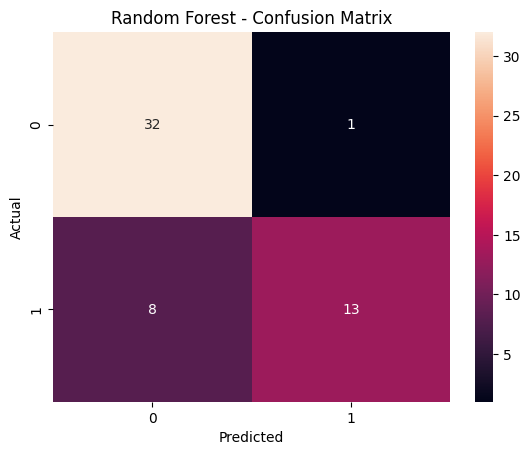


Model: Logistic Regression
Accuracy: 0.8703703703703703

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90        33
           1       0.94      0.71      0.81        21

    accuracy                           0.87        54
   macro avg       0.89      0.84      0.86        54
weighted avg       0.88      0.87      0.87        54



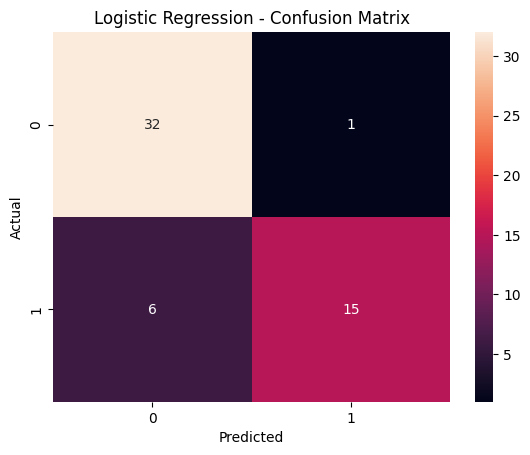


Model: SVM
Accuracy: 0.8148148148148148

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.86        33
           1       0.82      0.67      0.74        21

    accuracy                           0.81        54
   macro avg       0.82      0.79      0.80        54
weighted avg       0.82      0.81      0.81        54



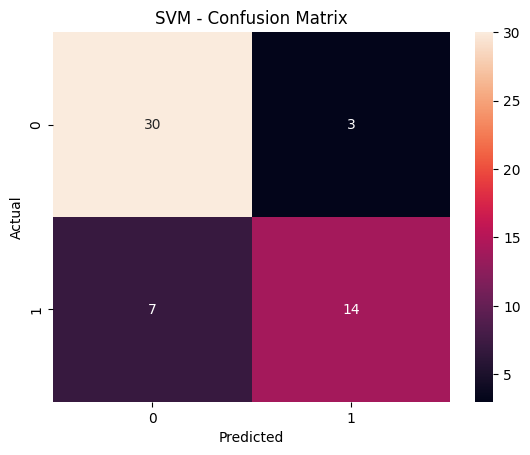


Model: KNN
Accuracy: 0.7777777777777778

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        33
           1       0.76      0.62      0.68        21

    accuracy                           0.78        54
   macro avg       0.77      0.75      0.76        54
weighted avg       0.78      0.78      0.77        54



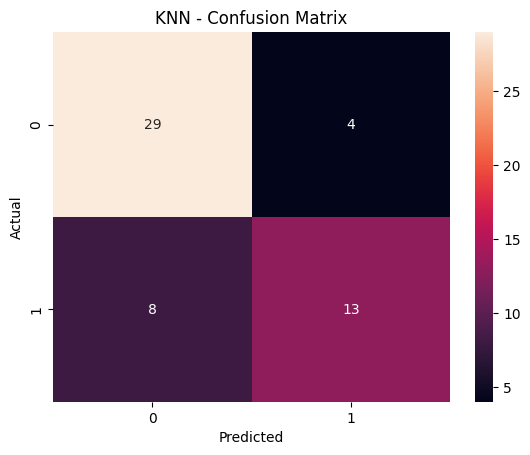

In [57]:
for name, model in models.items():
    print("\n==============================")
    print(f"Model: {name}")
    print("==============================")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

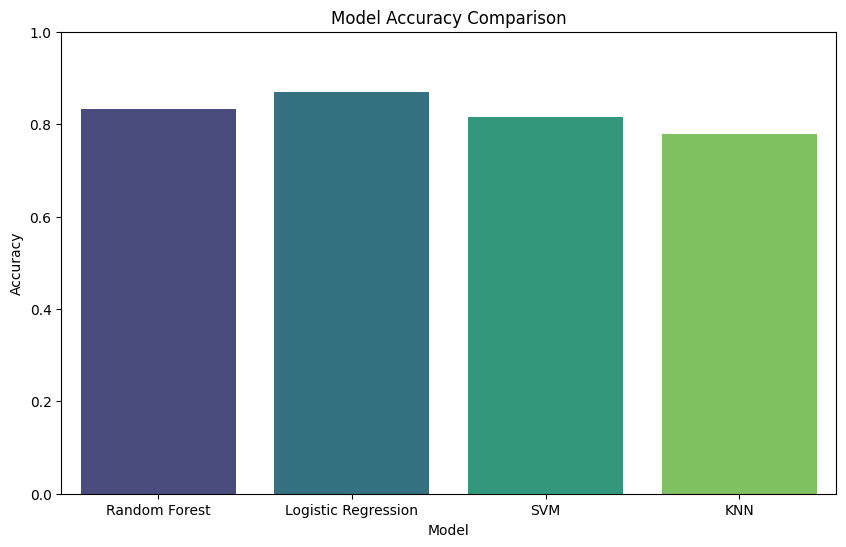

In [58]:
model_accuracies = {}
for name, model in models.items():
    # Assuming model has already been trained in the previous cell
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    model_accuracies[name] = acc

# Convert to DataFrame for easier plotting
accuracy_df = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, hue='Model', legend=False, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.show()

In [60]:
logistic_regression_model = models["Logistic Regression"]

sample_data = [
    55,
    1,
    130,
    250,
    0,
    150,
    0,
    1.0,
    0,
    False,
    False,
    False,
    False,
    False,
    False,
    False,
    False,
    False
]

sample_df = pd.DataFrame([sample_data], columns=X.columns)
sample_scaled = scaler.transform(sample_df)


prediction = logistic_regression_model.predict(sample_scaled)
prediction_proba = logistic_regression_model.predict_proba(sample_scaled)

print(f"Prediction for the sample data point: {'Disease' if prediction[0] == 1 else 'No Disease'}")
print(f"Prediction probabilities (No Disease, Disease): {prediction_proba[0]}")


Prediction for the sample data point: No Disease
Prediction probabilities (No Disease, Disease): [0.92295359 0.07704641]
